### Training convergence with confidence intervals

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.plot_utils import plot_convergence_ci

from utils.analyse_results import GraphsTraining, Results, plot_time_bands, load_all_pickles

train_info = GraphsTraining()

## Pyomo results

### [2, 16, 2]

In [19]:
fp_p1 = "results/study_ho/pyomo_ho_2_16_2_10_part_1.pkl"
fp_p2 = "results/study_ho/pyomo_ho_2_16_2_10_part_2.pkl"
results_li_p1 = Results.load_results(fp_p1)
results_li_p2 = Results.load_results(fp_p2)
results_li_16 = results_li_p1 + results_li_p2
results_df_16 = Results.flatten_convergence_data(results_li_16, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

In [20]:
fp_p1 = "results/study_ho/pyomo_ho_2_32_2_10_part_1.pkl"
fp_p2 = "results/study_ho/pyomo_ho_2_32_2_10_part_2.pkl"
results_li_p1 = Results.load_results(fp_p1)
results_li_p2 = Results.load_results(fp_p2)
results_li_32 = results_li_p1 + results_li_p2
results_df_32 = Results.flatten_convergence_data(results_li_32, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

In [21]:
fp_p1 = "results/study_ho/pyomo_ho_2_64_2_10_part_1.pkl"
results_li_64 = Results.load_results(fp_p1)
results_df_64 = Results.flatten_convergence_data(results_li_64, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

----
# HO comparison

#### pyomo

In [22]:
fp_p1 = "results/study_ho/pyomo_ho_2_32_2_10_part_1.pkl"
fp_p2 = "results/study_ho/pyomo_ho_2_32_2_10_part_2.pkl"
results_li_p1 = Results.load_results(fp_p1)
results_li_p2 = Results.load_results(fp_p2)
results_li_32 = results_li_p1 + results_li_p2
pyomo_results_df_32 = Results.flatten_convergence_data(results_li_32, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

In [23]:
pyomo_comparison_dfs = {
    "pyomo_16": results_df_16,
    "pyomo_32": results_df_32,
    "pyomo_64": results_df_64,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:514: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


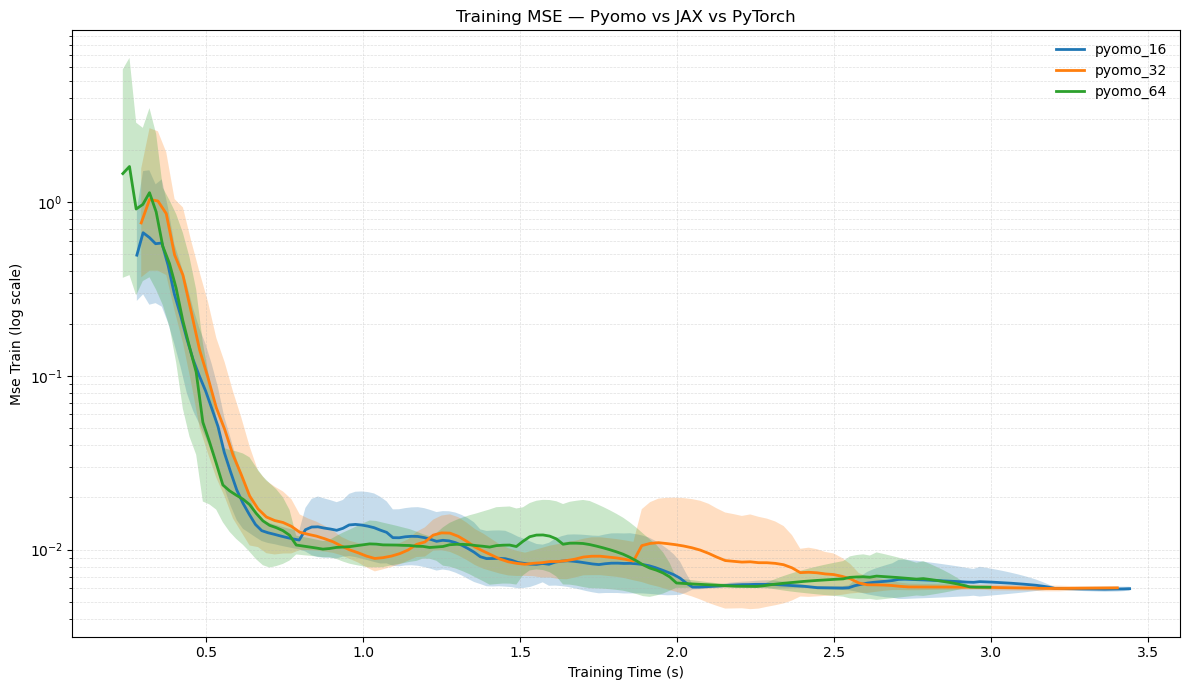

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [24]:
plot_time_bands(
    pyomo_comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False,
    extrapolate=False
)

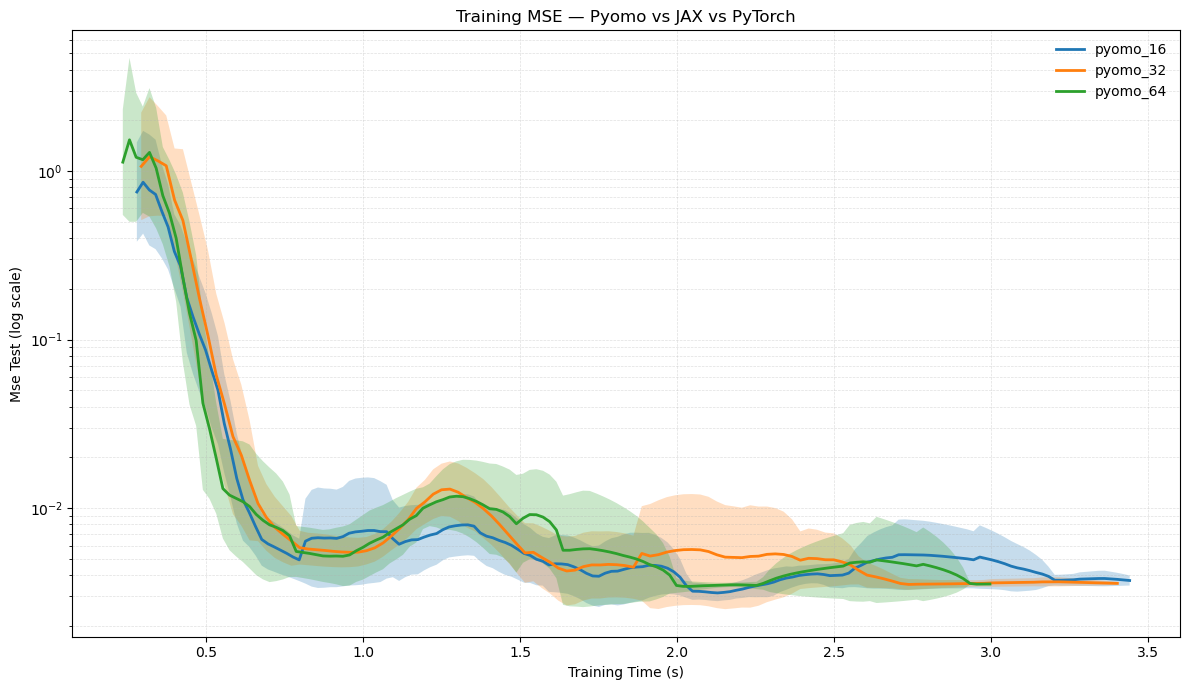

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [25]:
plot_time_bands(
    pyomo_comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False,
    extrapolate=False
)

#### pytorch

In [26]:
fp = "results/study_ho/pytoch_ho_400_pretrain_1000.pkl"
results = Results.load_results(fp)
pytoch_results_df_400 = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

fp = "results/study_ho/pytoch_ho_200_pretrain_1000.pkl"
results = Results.load_results(fp)
pytoch_results_df_200 = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

fp = "results/study_ho/pytoch_ho_no_pretrain_1000.pkl"
results = Results.load_results(fp)
pytoch_results_df_no_pretrain = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

In [27]:
pytorch_comparison_dfs = {
    "pytorch_no_pretrain": pytoch_results_df_no_pretrain,
    "pytorch_200": pytoch_results_df_200,
    "pytorch_400": pytoch_results_df_400,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:514: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


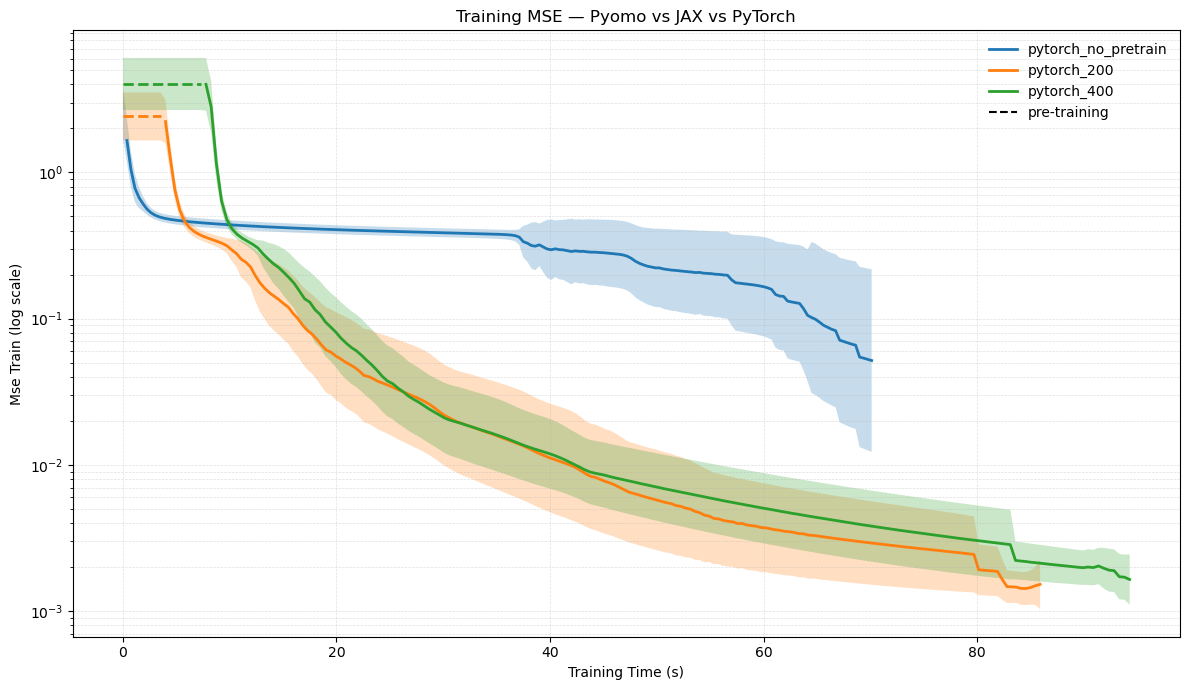

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [28]:
plot_time_bands(
    pytorch_comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)

### jax

In [29]:
results = load_all_pickles("results/study_ho/jax_ho_1000_10000", recursive=False)
jax_results_df_1000 = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="jax")

results = load_all_pickles("results/study_ho/jax_ho_500_10000", recursive=False)
jax_results_df_500 = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="jax")

results = load_all_pickles("results/study_ho/jax_ho_15000", recursive=False)
jax_results_df_no_pretrain = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="jax")

Loaded results/study_ho/jax_ho_1000_10000/1011631595_2025-11-08_19-54.pkl
Loaded results/study_ho/jax_ho_1000_10000/1097399737_2025-11-08_20-19.pkl
Loaded results/study_ho/jax_ho_1000_10000/1265876458_2025-11-08_20-23.pkl
Loaded results/study_ho/jax_ho_1000_10000/1323816387_2025-11-08_20-16.pkl
Loaded results/study_ho/jax_ho_1000_10000/1670734884_2025-11-08_20-01.pkl
Loaded results/study_ho/jax_ho_1000_10000/196384467_2025-11-08_20-41.pkl
Loaded results/study_ho/jax_ho_1000_10000/2263096188_2025-11-08_20-30.pkl
Loaded results/study_ho/jax_ho_1000_10000/2405860630_2025-11-08_20-12.pkl
Loaded results/study_ho/jax_ho_1000_10000/266273080_2025-11-08_20-33.pkl
Loaded results/study_ho/jax_ho_1000_10000/267864042_2025-11-08_20-37.pkl
Loaded results/study_ho/jax_ho_1000_10000/2988849674_2025-11-08_19-51.pkl
Loaded results/study_ho/jax_ho_1000_10000/3273264452_2025-11-08_19-58.pkl
Loaded results/study_ho/jax_ho_1000_10000/3301052970_2025-11-08_20-08.pkl
Loaded results/study_ho/jax_ho_1000_10000

In [30]:
jax_comparison_dfs = {
    "JAX_no_pretrain": jax_results_df_no_pretrain,
    "JAX 500": jax_results_df_500,
    "JAX 1000": jax_results_df_1000,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:514: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


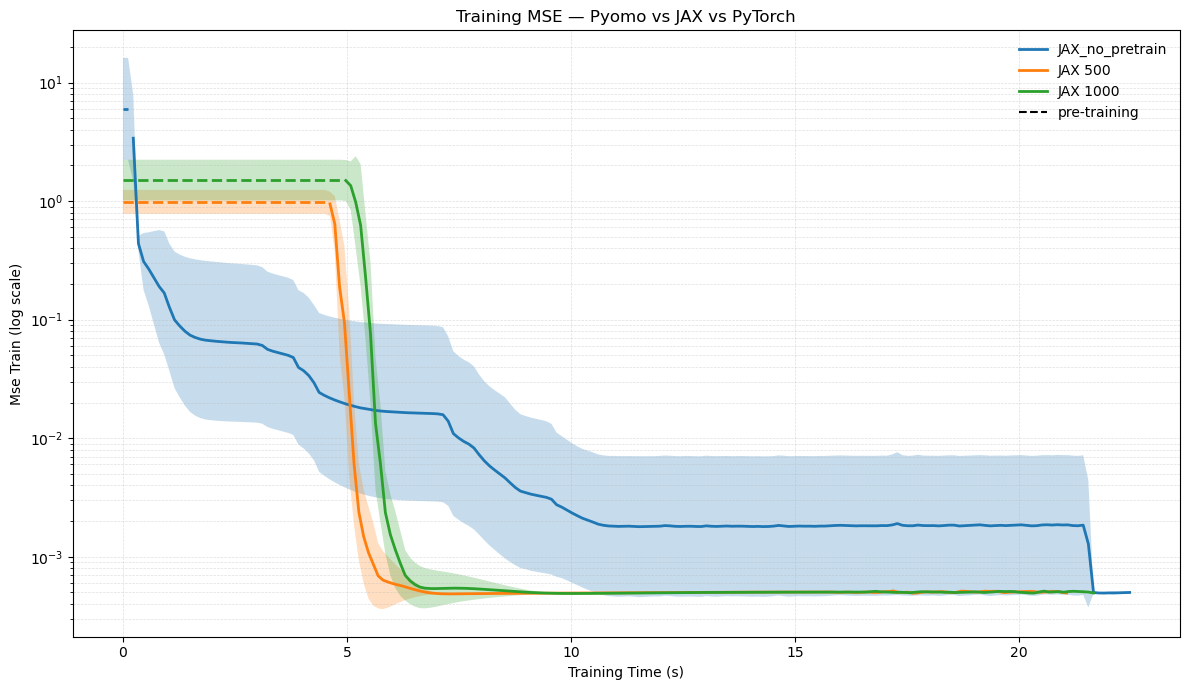

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [31]:
plot_time_bands(
    jax_comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)

In [32]:
comparison_dfs = {
    "Pyomo": pyomo_results_df_32,
    "JAX": jax_results_df_500,
    "PyTorch": pytoch_results_df_200,
}
max_q_maps = {
    "Pyomo": 1.0,
    "JAX": 0.85,
    "PyTorch": 0.85,
}

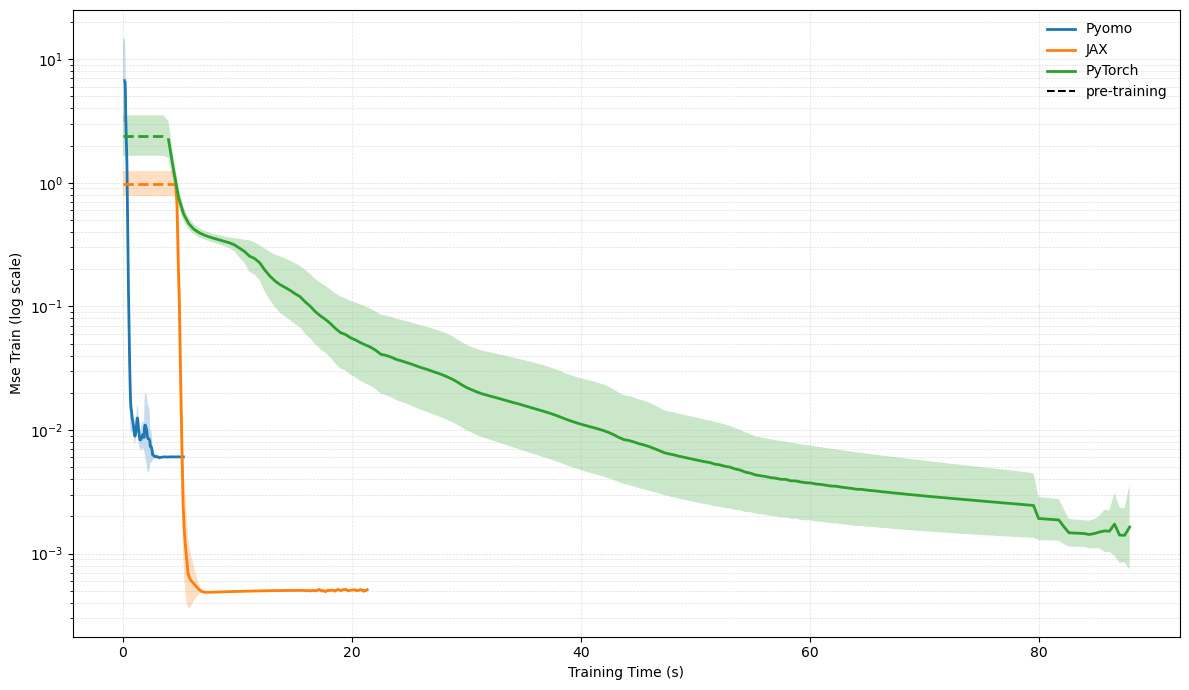

<Axes: xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [33]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    tmax_quantile = max_q_maps,
    extrapolate=True,
    cutoff_missing_frac = 1.0
)

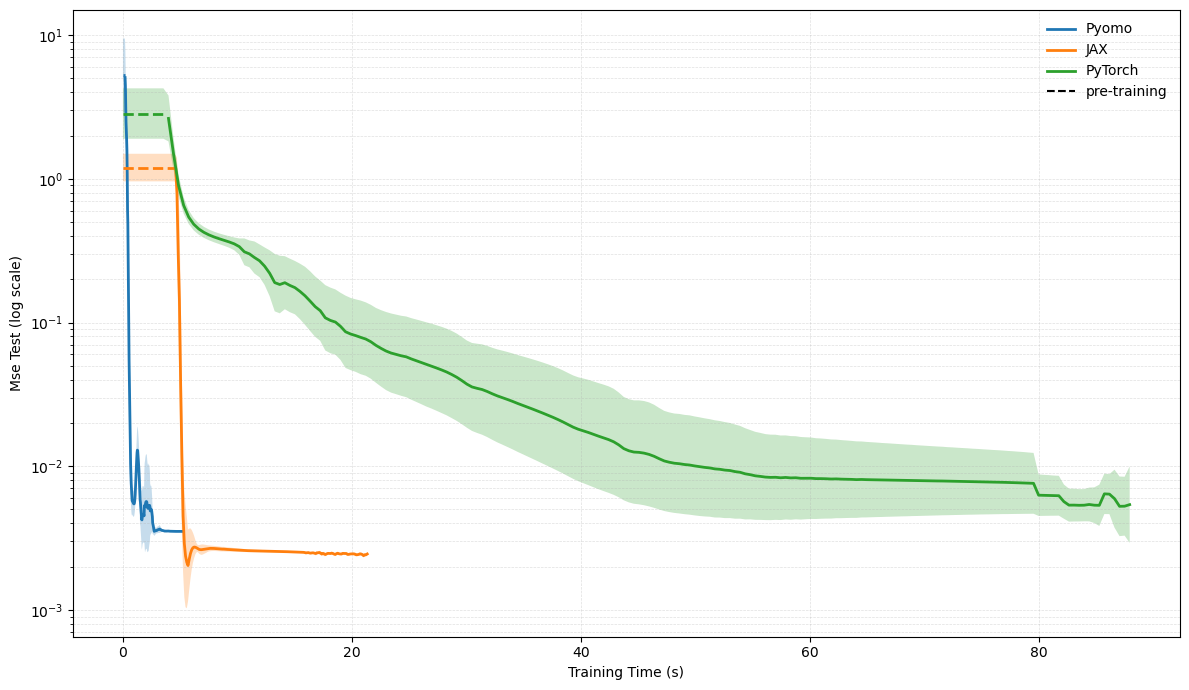

<Axes: xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [34]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    tmax_quantile = max_q_maps,
    extrapolate=True,
    cutoff_missing_frac = 1.0
)